# Import Modules

In [1]:
import importlib
import os
import sys

import joblib
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
os.chdir("../")
sys.path.insert(0, os.getcwd())

In [3]:
from morai.experience import charters, experience
from morai.forecast import metrics, preprocessors
from morai.models import neural
from morai.utils import custom_logger, helpers

In [4]:
logger = custom_logger.setup_logging(__name__)

In [5]:
# update log level if wanting more logging
custom_logger.set_log_level("INFO")

In [6]:
pd.options.display.float_format = "{:,.2f}".format

In [7]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

In [8]:
os.getcwd()

'C:\\Users\\johnk\\Desktop\\github\\morai'

# Data

In [9]:
pl_parquet_path = r"files/dataset/mortality_grouped.parquet"

In [10]:
# reading in the dataset
# `enable_string_cache` helps with categorical type values
pl.enable_string_cache()
lzdf = pl.scan_parquet(
    pl_parquet_path,
)

In [11]:
initial_row_count = lzdf.select(pl.len()).collect().item()
print(
    f"row count: {initial_row_count:,} \n"
    f"exposures: {lzdf.select([pl.col('amount_exposed').sum()]).collect()[0,0]:,}"
)

row count: 1,522,971 
exposures: 9,054,258,435,620.062


In [12]:
grouped_df = lzdf.collect()

In [13]:
grouped_df = grouped_df.to_pandas()

# Preparing Data

## Filter

In [14]:
model_data = grouped_df[
    (grouped_df["attained_age"] >= 50)
    # & (grouped_df["attained_age"] <= 95)
    & (grouped_df["issue_age"] >= 30)
    & (grouped_df["issue_age"] <= 80)
].copy()
model_data = model_data.reset_index(drop=True)

In [15]:
model_data.columns

Index(['observation_year', 'sex', 'smoker_status', 'insurance_plan',
       'issue_age', 'duration', 'face_amount_band', 'issue_year',
       'attained_age', 'soa_post_lvl_ind', 'number_of_pfd_classes',
       'preferred_class', 'amount_exposed', 'policies_exposed',
       'death_claim_amount', 'death_count', 'cen2momp1wmi_byamt',
       'cen2momp2wmi_byamt', 'class_enh', 'qx_vbt15', 'qx_raw', 'qx_log_raw',
       'exp_amt_vbt15', 'ae_vbt15', '__index_level_0__'],
      dtype='object')

In [16]:
del grouped_df

## Calculated Fields

In [17]:
model_data["capped_duration"] = model_data["duration"].clip(upper=26)
model_data["qx_log_raw"] = np.log(model_data["qx_raw"] + 1)
binned_face_dict = {
    "01: 0 - 9,999": "01: 0 - 24,999",
    "02: 10,000 - 24,999": "01: 0 - 24,999",
    "03: 25,000 - 49,999": "02: 25,000 - 99,999",
    "04: 50,000 - 99,999": "02: 25,000 - 99,999",
    "05: 100,000 - 249,999": "03: 100,000 - 249,999",
    "06: 250,000 - 499,999": "04: 250,000 - 4,999,999",
    "07: 500,000 - 999,999": "04: 250,000 - 4,999,999",
    "08: 1,000,000 - 2,499,999": "04: 250,000 - 4,999,999",
    "09: 2,500,000 - 4,999,999": "04: 250,000 - 4,999,999",
    "10: 5,000,000 - 9,999,999": "05: 5,000,000+",
    "11: 10,000,000+": "05: 5,000,000+",
}
model_data["binned_face"] = model_data["face_amount_band"].map(binned_face_dict)
model_data["binned_face"] = model_data["binned_face"].astype("category")

## Feature Dictionary

In [18]:
feature_dict = {
    "target": ["qx_raw"],
    "weight": ["amount_exposed"],
    "passthrough": [
        "attained_age",
        "duration",
        "observation_year",
        "binned_face",
        "insurance_plan",
        "class_enh",
    ],
    "ordinal": [
        "sex",
        "smoker_status",
    ],
    "nominal": [],
}

feature_dict_vbt = {
    "target": ["qx_raw"],
    "weight": ["amount_exposed"],
    "passthrough": ["attained_age", "duration"],
    "ordinal": [
        "sex",
        "smoker_status",
    ],
    "ohe": [],
    "nominal": [],
}

## Model Results Dictionary

In [19]:
metric_cols = ["ae", "smape", "r2_score", "root_mean_squared_error", "aic", "shape"]
model_results = metrics.ModelResults(metrics=metric_cols)

### VBT15

In [20]:
model_name = "vbt15"

In [21]:
scorecard = model_results.get_scorecard(
    y_true_train=model_data["death_claim_amount"],
    y_pred_train=model_data[f"exp_amt_{model_name}"],
    weights_train=None,
)
model_results.add_model(
    model_name=model_name,
    data_path=pl_parquet_path,
    data_shape=model_data.shape,
    preprocess_dict=None,
    model_params=None,
    scorecard=scorecard,
    importance=None,
)

 2025-11-13 20:23:54 | morai.forecast.metrics | INFO     | Adding model 'vbt15' 


# Forecasting Models

## Neural

**Feature Preprocessing:**
  - NN - using embedding for categorical columns.
  - Scaling should be considered to ensure the features aren't overly weighted by larger values.

**Model Characteristics**
  - NN is a complex type of model

In [22]:
model_name = "neural"

In [23]:
preprocess_dict = preprocessors.preprocess_data(
    model_data,
    feature_dict=feature_dict,
    standardize=True,
)

 2025-11-13 20:23:58 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2025-11-13 20:23:59 | morai.forecast.preprocessors | INFO     | model weights: ['amount_exposed'] 
 2025-11-13 20:23:59 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['attained_age', 'observation_year', 'insurance_plan', 'class_enh', 'binned_face', 'duration'] 
 2025-11-13 20:23:59 | morai.forecast.preprocessors | INFO     | ordinal - ordinal encoded: ['smoker_status', 'sex'] 
 2025-11-13 20:23:59 | morai.forecast.preprocessors | INFO     | standardizing the data with StandardScaler 


In [24]:
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]
md_encoded = preprocess_dict["md_encoded"]
model_features = preprocess_dict["model_features"]

X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, random_state=0, test_size=0.2
)

In [25]:
model = neural.Neural(
    task="poisson",
    cat_cols=[
        "sex",
        "smoker_status",
        "insurance_plan",
        "observation_year",
        "class_enh",
        "binned_face",
    ],
)

 2025-11-13 20:24:03 | morai.models.neural | INFO     | initialized Neural model with Torch
task: poisson 
device: cpu 


In [26]:
model.fit(X=X_train, y=y_train, weights=weights_train, epochs=300, lr=0.001)

 2025-11-13 20:24:05 | morai.models.neural | INFO     | numeric columns: ['attained_age', 'duration'] 
 2025-11-13 20:24:05 | morai.models.neural | INFO     | categorical columns: ['sex', 'smoker_status', 'insurance_plan', 'observation_year', 'class_enh', 'binned_face'] 
 2025-11-13 20:24:05 | morai.models.neural | INFO     | dropout: 0.0 
 2025-11-13 20:24:06 | morai.models.neural | INFO     | created embeddings for `{'sex': 2, 'smoker_status': 2, 'insurance_plan': 4, 'observation_year': 5, 'class_enh': 6, 'binned_face': 3}` 
overall_mu: 0.0049835238180260906


Training:   0%|          | 0/300 [00:00<?, ?it/s]

In [27]:
predictions = model.predict(X)

In [28]:
model_data = experience.calc_qx_exp_ae(
    model_data=model_data,
    predictions=predictions,
    model_name=model_name,
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

 2025-11-13 20:32:47 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [exp_amt_neural] 
 2025-11-13 20:32:47 | morai.experience.charters | INFO     | Binning feature: [duration] with 8 bins 


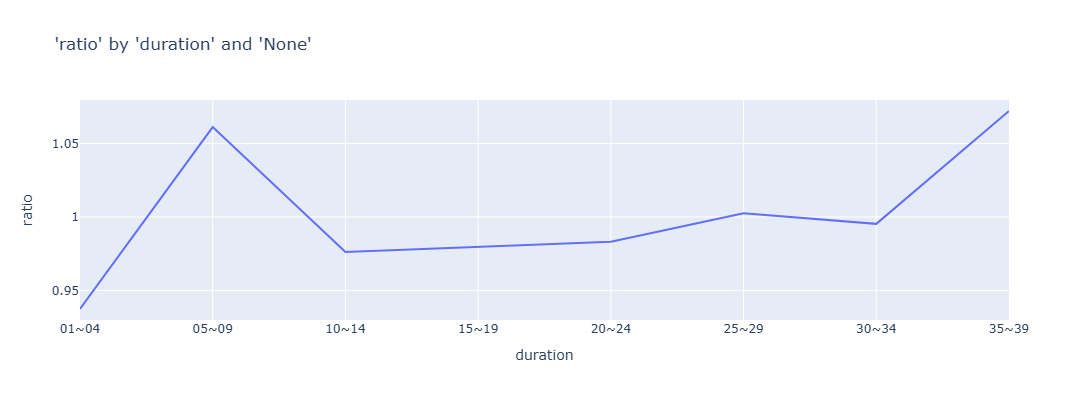

In [29]:
charters.chart(
    df=model_data,
    x_axis="duration",
    y_axis="ratio",
    numerator="death_claim_amount",
    denominator="exp_amt_neural",
    x_bins=8,
    type="line",
)

 2025-11-13 20:32:56 | morai.experience.charters | INFO     | The weights list is 1 long and should be 3 long. Using the first weight for all weights. 


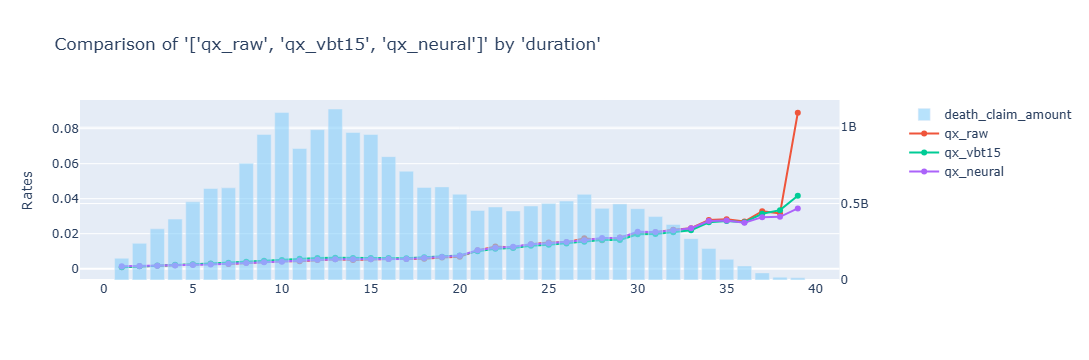

In [30]:
charters.compare_rates(
    model_data,
    x_axis="duration",
    rates=["qx_raw", "qx_vbt15", "qx_neural"],
    weights=["amount_exposed"],
    secondary="death_claim_amount",
    y_log=False,
)

 2025-11-13 20:33:04 | morai.experience.charters | INFO     | Creating '9' target plots. 


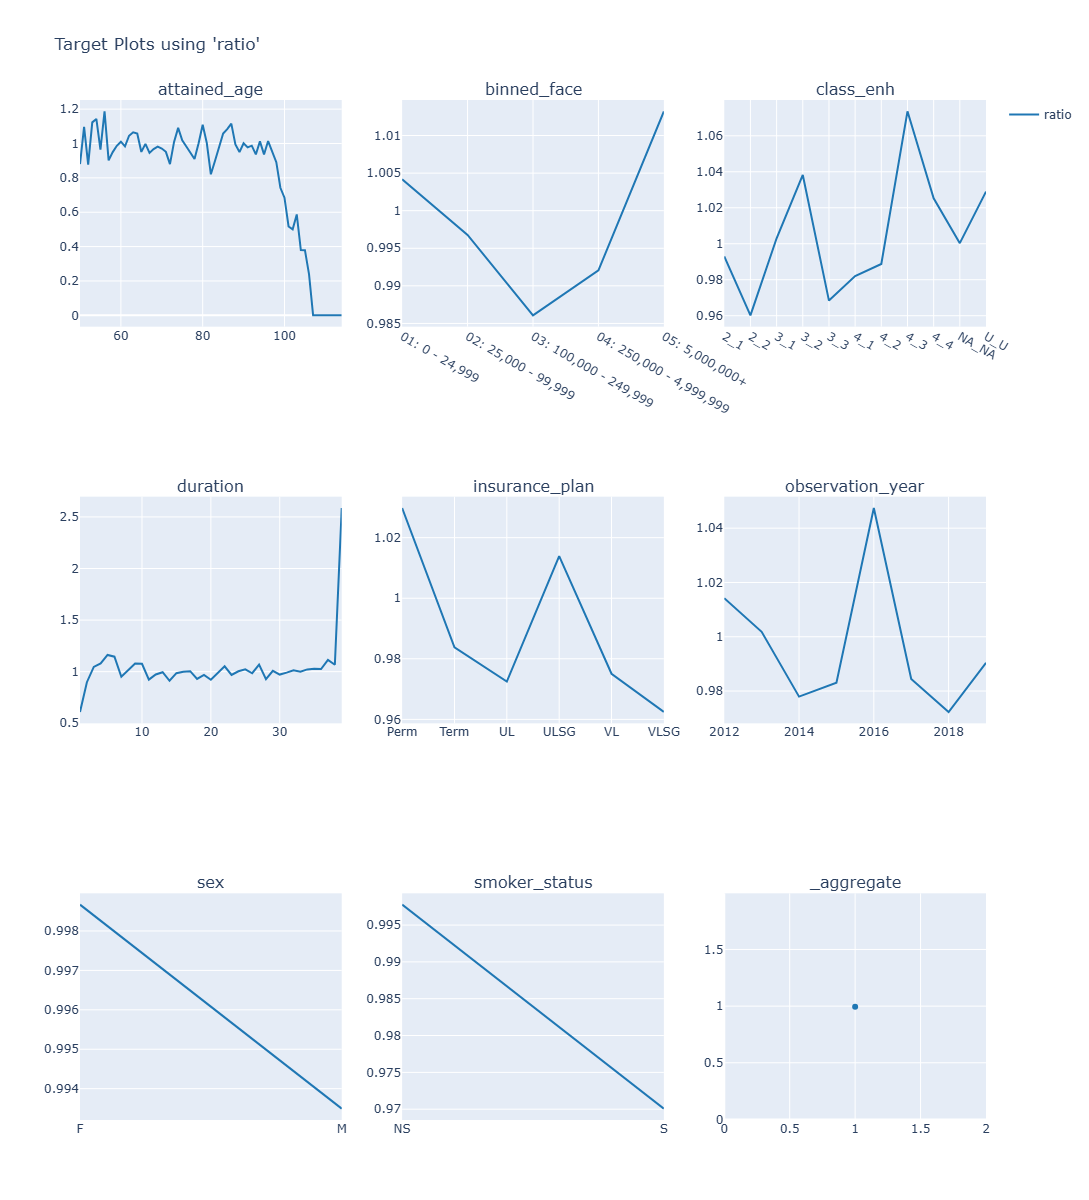

In [31]:
charters.target(
    df=model_data,
    target="ratio",
    cols=3,
    features=model_features,
    numerator=["death_claim_amount"],
    denominator=["exp_amt_neural"],
).show()

## PDP

In [32]:
model.feature_names

Index(['attained_age', 'binned_face', 'class_enh', 'duration',
       'insurance_plan', 'observation_year', 'sex', 'smoker_status'],
      dtype='object')

 2025-11-13 20:33:35 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2025-11-13 20:33:35 | morai.experience.charters | INFO     | Weights: [amount_exposed] 
 2025-11-13 20:33:35 | morai.experience.charters | INFO     | x_axis: [duration] type: [standardized] center: [global] 
 2025-11-13 20:33:35 | morai.experience.charters | INFO     | Line feature: [insurance_plan] type: [passthrough] 
 2025-11-13 20:33:35 | morai.experience.charters | INFO     | Creating 234 predictions. 


Processing:   0%|          | 0/234 [00:00<?, ?combo/s]

 2025-11-13 20:38:13 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


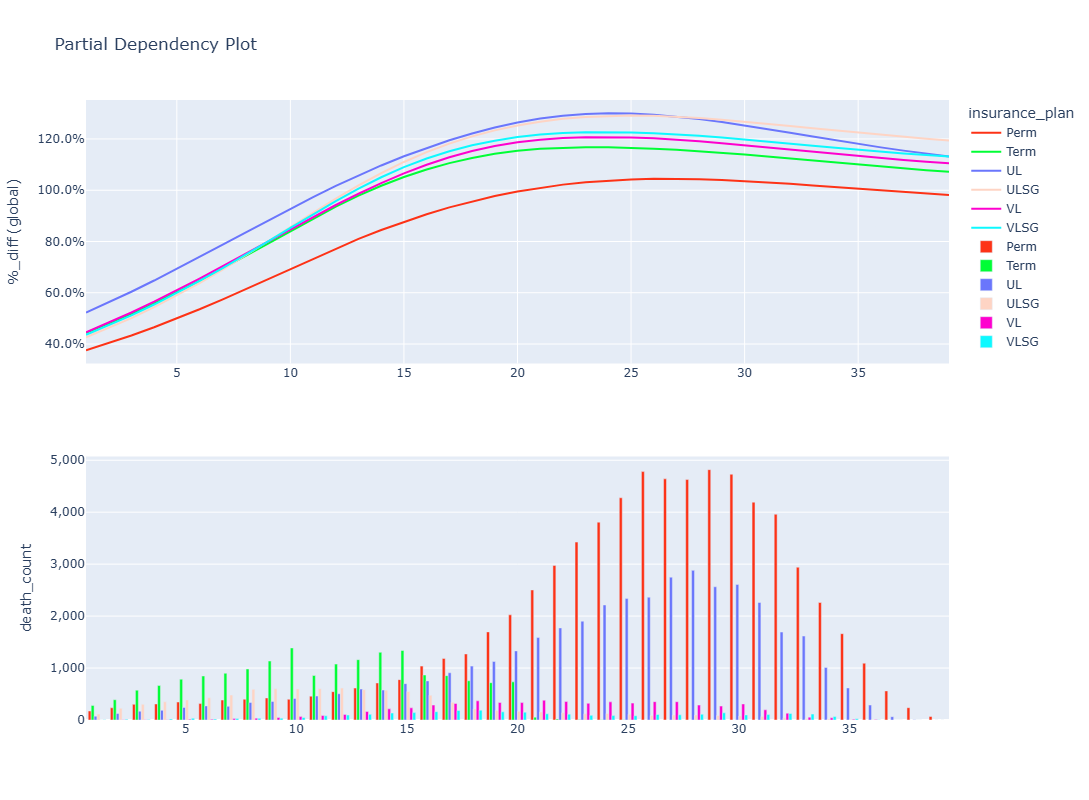

In [33]:
charters.pdp(
    model=model,
    df=md_encoded[
        (
            (md_encoded["duration"] <= 30)
        )
    ],
    x_axis="duration",
    line_color="insurance_plan",
    weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=True,
)

In [ ]:
charters.pdp(
    model=model,
    df=md_encoded[
        (
            (md_encoded["duration"] <= 30)
        )
    ],
    x_axis="duration",
    line_color="insurance_plan",
    # weight="amount_exposed",
    secondary="death_count",
    mapping=mapping,
    display=True,
)

 2025-11-13 20:38:13 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2025-11-13 20:38:14 | morai.experience.charters | INFO     | x_axis: [duration] type: [standardized] center: [global] 
 2025-11-13 20:38:14 | morai.experience.charters | INFO     | Line feature: [insurance_plan] type: [passthrough] 
 2025-11-13 20:38:14 | morai.experience.charters | INFO     | Creating 234 predictions. 


Processing:   0%|          | 0/234 [00:00<?, ?combo/s]

In [34]:
charters.pdp(
    model=model,
    df=md_encoded[
        (
            md_encoded["class_enh"].isin(["2_1", "2_2"])
            & (md_encoded["insurance_plan"] == "UL")
        )
    ],
    x_axis="attained_age",
    line_color="class_enh",
    secondary="death_count",
    mapping=mapping,
    center="per_x",
    display=True,
)

 2025-09-14 11:38:11 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2025-09-14 11:38:11 | morai.experience.charters | INFO     | x_axis: [attained_age] type: [standardized] center: [per_x] 
 2025-09-14 11:38:11 | morai.experience.charters | INFO     | Line feature: [class_enh] type: [passthrough] 
 2025-09-14 11:38:11 | morai.experience.charters | INFO     | Creating 114 predictions. 


Processing:   0%|          | 0/114 [00:00<?, ?combo/s]

 2025-09-14 11:38:28 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


In [36]:
charters.pdp(
    model=model,
    df=md_encoded,
    x_axis="attained_age",
    line_color="binned_face",
    secondary="death_count",
    mapping=mapping,
    center="per_x",
    display=True,
)

 2025-09-14 11:45:30 | morai.experience.charters | INFO     | Model: [Neural] for partial dependence plot. 
 2025-09-14 11:45:30 | morai.experience.charters | INFO     | x_axis: [attained_age] type: [standardized] center: [per_x] 
 2025-09-14 11:45:30 | morai.experience.charters | INFO     | Line feature: [binned_face] type: [passthrough] 
 2025-09-14 11:45:30 | morai.experience.charters | INFO     | Creating 320 predictions. 


Processing:   0%|          | 0/320 [00:00<?, ?combo/s]

 2025-09-14 11:53:46 | morai.experience.charters | INFO     | Adding secondary to chart: [death_count] 


# Reload

In [28]:
import importlib

In [188]:
importlib.reload(neural)

<module 'morai.models.neural' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\models\\neural.py'>